<a href="https://colab.research.google.com/github/1admgpwj-art/hatcho-app/blob/main/superstore_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import rcParams

# 日本語フォント設定
rcParams['font.family'] = 'DejaVu Sans'

# データ読み込み
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin-1')

# 基本情報を確認
print("データの行数・列数：", df.shape)
print("\n列名一覧：")
print(df.columns.tolist())
print("\n最初の3行：")
df.head(3)

データの行数・列数： (9994, 21)

列名一覧：
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

最初の3行：


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


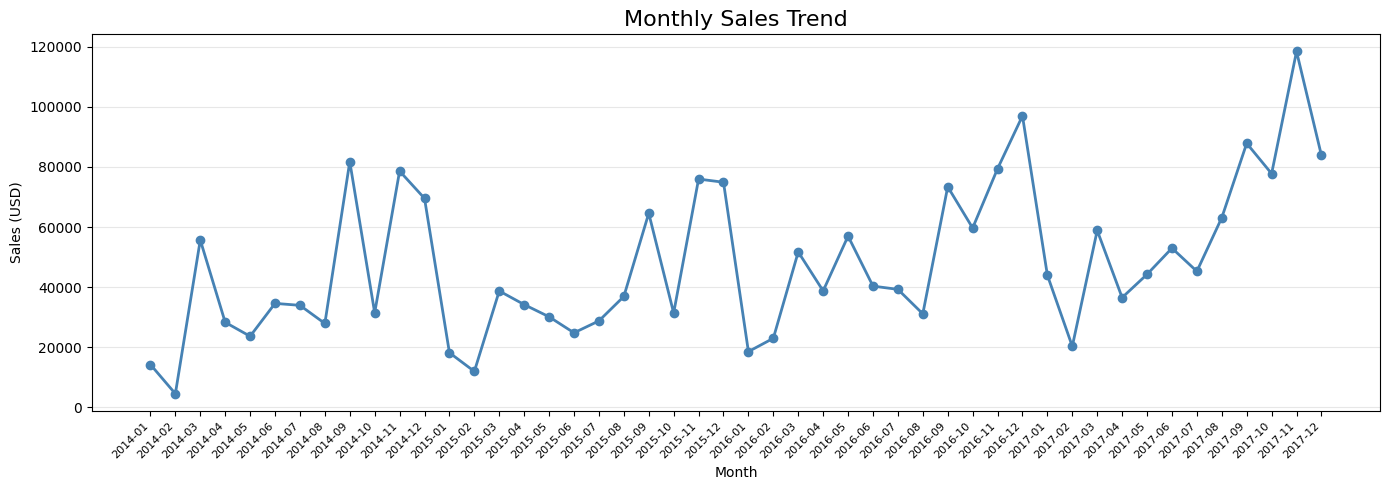

完了


In [3]:
# 月別売上の推移を可視化する

# 日付をdate型に変換
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 月ごとに集計
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# グラフ作成
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', linewidth=2, color='steelblue')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("完了")

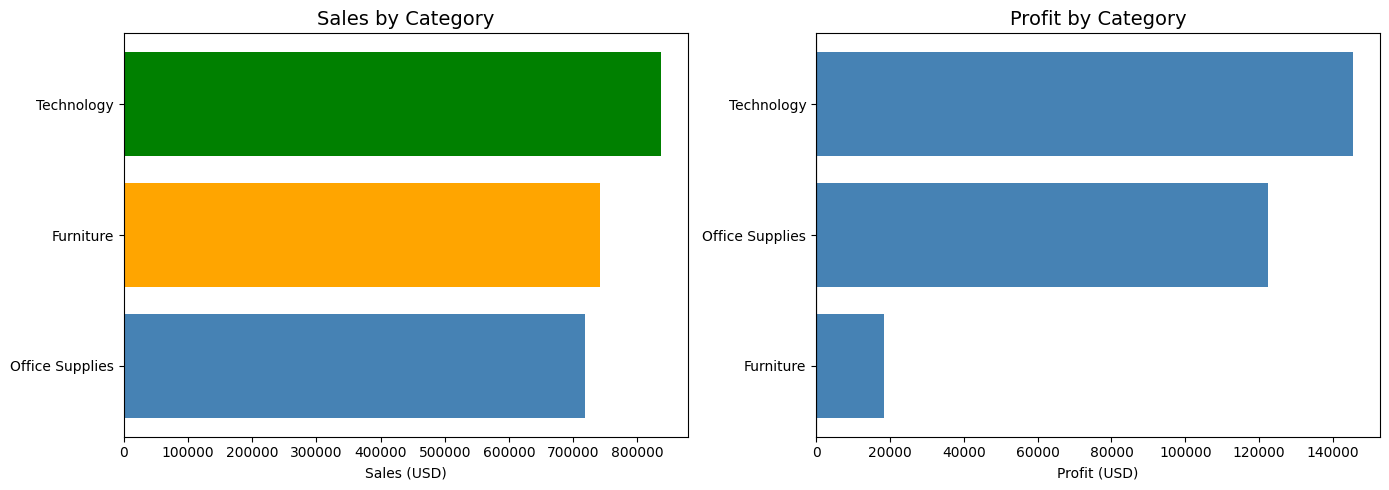

=== カテゴリ別 売上・利益 ===
                       Sales       Profit  Profit Margin
Category                                                
Furniture        741999.7953   18451.2728            2.5
Office Supplies  719047.0320  122490.8008           17.0
Technology       836154.0330  145454.9481           17.4


In [4]:
# カテゴリ別・サブカテゴリ別の売上と利益

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# カテゴリ別売上
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
axes[0].barh(category_sales.index, category_sales.values, color=['steelblue', 'orange', 'green'])
axes[0].set_title('Sales by Category', fontsize=14)
axes[0].set_xlabel('Sales (USD)')

# カテゴリ別利益
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=True)
colors = ['red' if x < 0 else 'steelblue' for x in category_profit.values]
axes[1].barh(category_profit.index, category_profit.values, color=colors)
axes[1].set_title('Profit by Category', fontsize=14)
axes[1].set_xlabel('Profit (USD)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# 数字で確認
print("=== カテゴリ別 売上・利益 ===")
summary = df.groupby('Category')[['Sales', 'Profit']].sum()
summary['Profit Margin'] = (summary['Profit'] / summary['Sales'] * 100).round(1)
print(summary)

平均絶対誤差（MAE）: $18,042
決定係数（R²）: 0.034

※ R²は1.0が完璧な予測。0.5以上であれば一定の予測力あり


/tmp/ipykernel_1666/3906425959.py:41: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3906425959.py:41: UserWarning: Glyph 32318 (\N{CJK UNIFIED IDEOGRAPH-7E3E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3906425959.py:41: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3906425959.py:41: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32318 (\N{CJK UNIFIED IDEOGRAPH-7E3E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

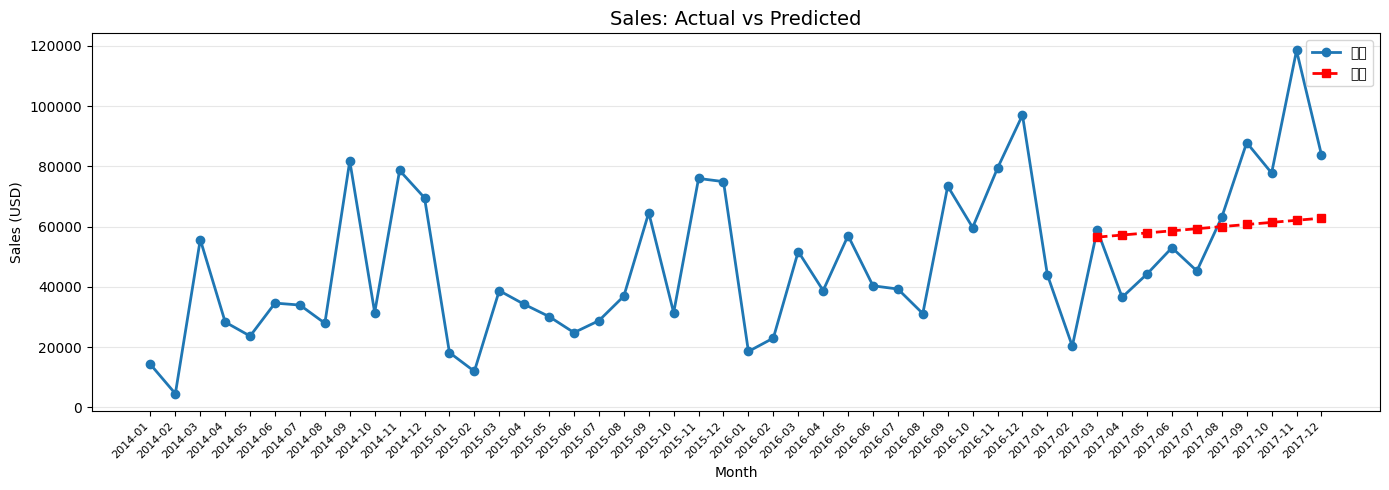

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 月別売上データを数値に変換
monthly_sales['Month_Num'] = range(len(monthly_sales))

X = monthly_sales[['Month_Num']]
y = monthly_sales['Sales']

# 学習データ（80%）とテストデータ（20%）に分割
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# モデルを作成・学習
model = LinearRegression()
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 精度を確認
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"平均絶対誤差（MAE）: ${mae:,.0f}")
print(f"決定係数（R²）: {r2:.3f}")
print(f"\n※ R²は1.0が完璧な予測。0.5以上であれば一定の予測力あり")

# グラフで実績vs予測を表示
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], label='実績', marker='o', linewidth=2)
plt.plot(monthly_sales['YearMonth'].iloc[split:], y_pred, label='予測', marker='s', linewidth=2, linestyle='--', color='red')
plt.title('Sales: Actual vs Predicted', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


【改善後】平均絶対誤差（MAE）: $11,424
【改善後】決定係数（R²）: 0.718

【比較】
線形回帰  R²: 0.034
Holt-Winters R²: 0.718


/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 32318 (\N{CJK UNIFIED IDEOGRAPH-7E3E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 25913 (\N{CJK UNIFIED IDEOGRAPH-6539}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1666/3926222789.py:41: UserWarning: Glyph 21892 (\N{CJK UNIFIED IDEOGRAPH-5584}

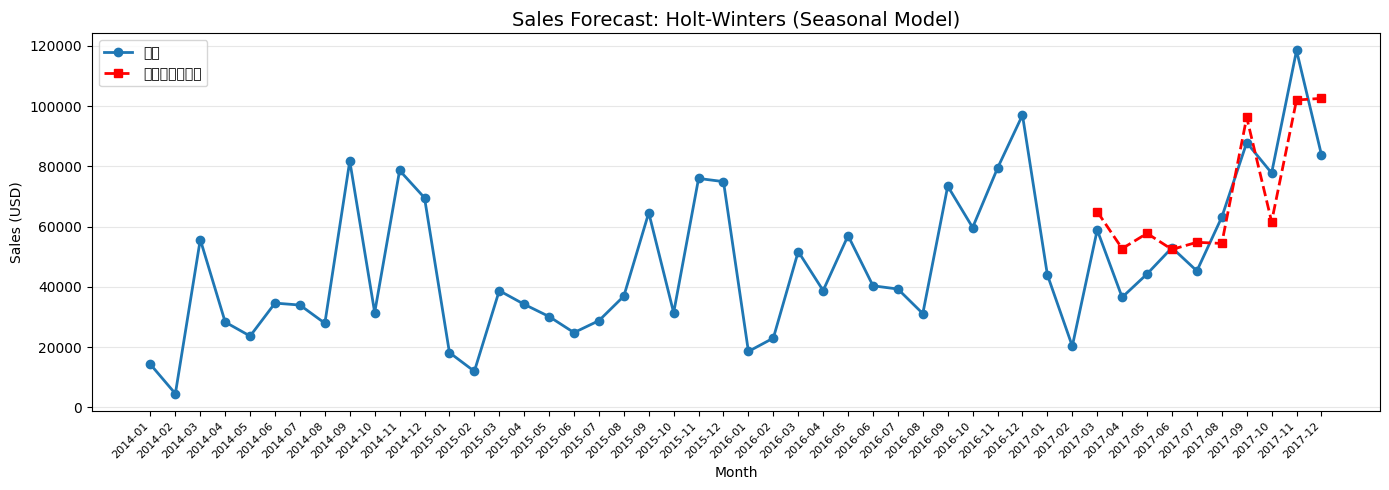

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 月別売上を時系列データに変換
monthly_sales_ts = monthly_sales.set_index('YearMonth')['Sales']

# 学習・テスト分割
split = int(len(monthly_sales_ts) * 0.8)
train = monthly_sales_ts.iloc[:split]
test = monthly_sales_ts.iloc[split:]

# 季節性を考慮したモデル（Holt-Winters法）
model_hw = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
fitted_hw = model_hw.fit()
pred_hw = fitted_hw.forecast(len(test))

# 精度計算
mae_hw = mean_absolute_error(test.values, pred_hw.values)
r2_hw = r2_score(test.values, pred_hw.values)

print(f"【改善後】平均絶対誤差（MAE）: ${mae_hw:,.0f}")
print(f"【改善後】決定係数（R²）: {r2_hw:.3f}")
print(f"\n【比較】")
print(f"線形回帰  R²: 0.034")
print(f"Holt-Winters R²: {r2_hw:.3f}")

# グラフ
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales_ts.index, monthly_sales_ts.values, label='実績', marker='o', linewidth=2)
plt.plot(test.index, pred_hw.values, label='予測（改善後）', marker='s', linewidth=2, linestyle='--', color='red')
plt.title('Sales Forecast: Holt-Winters (Seasonal Model)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales (USD)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ビジネスインパクト試算

# 基本データ
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_monthly_sales = monthly_sales['Sales'].mean()

# Furniture の問題を深掘り
furniture = df[df['Category'] == 'Furniture']
furniture_sub = df[df['Category'] == 'Furniture'].groupby('Sub-Category')[['Sales', 'Profit']].sum()
furniture_sub['Profit Margin'] = (furniture_sub['Profit'] / furniture_sub['Sales'] * 100).round(1)
furniture_sub = furniture_sub.sort_values('Profit', ascending=True)

print("=== Furniture サブカテゴリ別 利益分析 ===")
print(furniture_sub)

# 赤字サブカテゴリの損失額
loss = furniture_sub[furniture_sub['Profit'] < 0]['Profit'].sum()
print(f"\n赤字サブカテゴリの損失合計: ${abs(loss):,.0f}")

# もし赤字カテゴリを改善・撤退したら
print(f"\n【ビジネスインパクト試算】")
print(f"現在の総利益: ${total_profit:,.0f}")
print(f"赤字カテゴリ損失分: ${abs(loss):,.0f}")
print(f"改善した場合の利益増加率: {abs(loss)/total_profit*100:.1f}%")

# 可視化
fig, ax = plt.subplots(figs

SyntaxError: incomplete input (2750299405.py, line 28)

=== Furniture サブカテゴリ別 利益分析 ===
                    Sales      Profit  Profit Margin
Sub-Category                                        
Tables        206965.5320 -17725.4811           -8.6
Bookcases     114879.9963  -3472.5560           -3.0
Furnishings    91705.1640  13059.1436           14.2
Chairs        328449.1030  26590.1663            8.1

赤字サブカテゴリの損失合計: $21,198

【ビジネスインパクト試算】
現在の総利益: $286,397
赤字カテゴリ損失分: $21,198
改善した場合の利益増加率: 7.4%


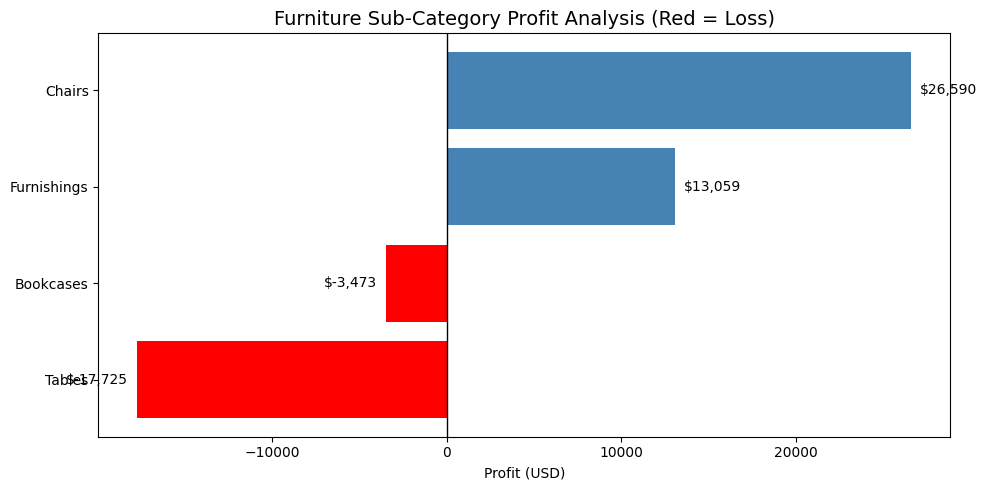

In [8]:
# ビジネスインパクト試算

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_monthly_sales = monthly_sales['Sales'].mean()

furniture_sub = df[df['Category'] == 'Furniture'].groupby('Sub-Category')[['Sales', 'Profit']].sum()
furniture_sub['Profit Margin'] = (furniture_sub['Profit'] / furniture_sub['Sales'] * 100).round(1)
furniture_sub = furniture_sub.sort_values('Profit', ascending=True)

print("=== Furniture サブカテゴリ別 利益分析 ===")
print(furniture_sub)

loss = furniture_sub[furniture_sub['Profit'] < 0]['Profit'].sum()
print(f"\n赤字サブカテゴリの損失合計: ${abs(loss):,.0f}")
print(f"\n【ビジネスインパクト試算】")
print(f"現在の総利益: ${total_profit:,.0f}")
print(f"赤字カテゴリ損失分: ${abs(loss):,.0f}")
print(f"改善した場合の利益増加率: {abs(loss)/total_profit*100:.1f}%")

colors = ['red' if x < 0 else 'steelblue' for x in furniture_sub['Profit']]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(furniture_sub.index, furniture_sub['Profit'], color=colors)
ax.set_title('Furniture Sub-Category Profit Analysis (Red = Loss)', fontsize=14)
ax.set_xlabel('Profit (USD)')
ax.axvline(x=0, color='black', linewidth=1)
for bar, val in zip(bars, furniture_sub['Profit']):
    ax.text(val + (500 if val >= 0 else -500), bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()
plt.show()